# 3D cartonization solver: Summary

This notebook demonstrates how the 3D cartonization solver works, why we have both **Fast** and **Best** modes, and how their recommendations compare with the existing iHub results.

At a high level, both modes use the same configurable packing rules and return a validated 3D packing plan.

**Fast** is designed to return a good packing plan quickly using our heuristic approach.

**Best** starts from Fast's result and searches further for a better solution within a bounded time limit. This gives it the opportunity to reduce the number of cartons or use a smaller carton, while still retaining Fast's validated result as a fallback.

The examples in this notebook walk through:

1. The carton catalogue and packing rules supplied to the solver.
2. How item dimensions, weight, rotation and fill limits affect whether a carton is valid.
3. How Fast and Best behave on real sample orders.
4. Cases where Best improves on Fast or the existing iHub result.
5. Performance across the full 2,000-order development dataset.
6. A check that the existing iHub answer is used only for comparison and does not influence the solver recommendation.

The goal is not just to show that the solver returns a carton, but to make it clear **why that carton was selected and whether the result is valid**.

## Units

The source data and solver use the same units throughout:

- Item and carton dimensions: **millimetres (mm)**
- Buffer and packed XYZ coordinates: **millimetres (mm)**
- Derived volumes: **cubic millimetres (mm³)**
- Item and carton weight: **kilograms (kg)**

No unit conversion is required. Order identifiers and item codes in the development dataset are masked.

In [1]:
import copy
import inspect
import json
import math
import statistics
from contextlib import redirect_stdout
from html import escape as html_escape
from io import StringIO
from pathlib import Path
import sys

from IPython.display import HTML, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from bin_packing_3d import (
    PackingObjective, display_table, make_table, packing_objective,
    result_tables, solve_order, visualize_result,
)

def show_details(summary, content):
    body = content._repr_html_() if hasattr(content, '_repr_html_') else f'<pre>{html_escape(str(content))}</pre>'
    display(HTML(f'<details><summary><strong>{html_escape(summary)}</strong></summary>{body}</details>'))

## 1. The contract is configurable—not hidden

The user supplies the order and carton catalogue directly to `solve_order()`. The package owns the operational defaults: a 70% high-item-count fill cap, 6 mm height clearance, weight limits, and rotation rules. Callers can override the configurable defaults when required. The detailed catalogue is reference material, so it is collapsed by default.

In [2]:
DATA_PATH = ROOT / 'data' / 'raw' / 'data_samples_v2.json'
with DATA_PATH.open(encoding='utf-8') as file:
    ihub_records = {record['input']['OrderId']: record for record in json.load(file)}

catalogue_source = next(iter(ihub_records.values()))['input']
boxes = [dict(box) for box in catalogue_source['Bins']['BinsList']]
box_rows = [
    {
        'Code': box['Code'], 'Length (mm)': box['Length'],
        'Width (mm)': box['Width'], 'Height (mm)': box['Height'],
        'Max weight (kg)': box['MaxWeight'],
    }
    for box in boxes
]
show_details('Show the six candidate cartons', make_table(box_rows))

Code,Length (mm),Width (mm),Height (mm),Max weight (kg)
Box2,270.0,170.0,115.0,20
Box4,340.0,260.0,150.0,20
Box5,340.0,260.0,235.0,20
Box6,340.0,260.0,280.0,20
Box8,290.0,180.0,280.0,20
Box9,440.0,345.0,280.0,20


### Rules visible at the call boundary

The values below are read from the public `solve_order()` signature, not copied from the development dataset. The normal examples rely on these package defaults directly. The separate override example only shows how a caller can choose different values. Logging and visualization are explicit options and do not change the solution.

In [3]:
solver_parameters = inspect.signature(solve_order).parameters
default_buffer = solver_parameters['bin_buffer'].default
display_table([
    {'Rule': 'Default mode', 'Package default': solver_parameters['mode'].default},
    {'Rule': 'Full-fill item threshold', 'Package default': solver_parameters['high_item_count_threshold'].default},
    {'Rule': 'Maximum fill above threshold', 'Package default': f"{solver_parameters['high_item_count_max_fill_pct'].default}%"},
    {'Rule': 'Maximum fill at/below threshold', 'Package default': f"{solver_parameters['max_fill_pct'].default}%"},
    {'Rule': 'Carton clearance (L × W × H)', 'Package default': f'{default_buffer.length:g} × {default_buffer.width:g} × {default_buffer.height:g} mm'},
])

optional_overrides = {
    'high_item_count_threshold': 8,
    'high_item_count_max_fill_pct': 75,
    'max_fill_pct': 95,
    'bin_buffer': {'length': 2, 'width': 2, 'height': 8},
}
show_details('Show an optional configuration override', make_table([optional_overrides]))

Rule,Package default
Default mode,fast
Full-fill item threshold,6
Maximum fill above threshold,70%
Maximum fill at/below threshold,100%
Carton clearance (L × W × H),0 × 0 × 6 mm


high_item_count_threshold,high_item_count_max_fill_pct,max_fill_pct,bin_buffer
8,75,95,"{'length': 2, 'width': 2, 'height': 8}"


## 2. What the solver calculates under the hood

The solver does not predict an iHub carton. It builds a packing from the supplied items, cartons, and rules. The calculation proceeds in this order:

| Stage | Calculation | Decision produced |
| --- | --- | --- |
| Expand demand | One physical instance per `Quantity` unit | Stable IDs such as `SKU#1`, `SKU#2` |
| Apply clearance | `usable axis = external axis - configured buffer` | The 6 mm height buffer reduces every candidate carton |
| Select fill policy | Use `max_fill_pct` at/below the item threshold; above it use the smaller of the normal and high-count caps | Orders with more than six items are capped at 70% here |
| Screen cartons | Check individual orientation, aggregate weight, and `item volume ≤ usable volume × fill cap` | Impossible candidates are rejected cheaply; passing is not yet proof |
| Fast construction | Order larger items first, score feasible XYZ placements, and try promising fixed-carton combinations | A complete validated fallback plan |
| Best feasibility | For each carton combination, solve orientation, carton assignment, XYZ boundary, pairwise non-overlap, weight, and fill constraints together | Exact yes/no feasibility for that combination |
| Optimize | Test combinations by `(carton count, largest external carton volume, total external carton volume)` | The first feasible combination is the preferred objective |
| Validate independently | Recheck accounting, orientation, boundaries, collision, weight, fill, and carton identity without trusting the solver | Only a validated plan can be returned |

Best can claim `optimality_proven=True` only when every better carton combination was proven infeasible. If the time budget expires, it returns Fast's already validated plan with `search_status='time_limit'`. This is exact feasibility inside a bounded search—not a learned model and not a lookup of the reference answer.

## 3. Start with the full benchmark: 2,000 orders

The demo starts with the full development benchmark rather than selected examples.

Every packing comparison follows the same priority:

1. **Respect the supplied packing policy**
2. **Use the fewest cartons**
3. **Use the smallest largest carton**
4. **Use the smallest total carton volume**

Latency is analysed separately. A faster result is not better if the packing decision is invalid or objectively worse.

In [4]:
sys.path.insert(0, str(ROOT / 'notebooks'))
from benchmark_solver_modes import benchmark, benchmark_mode, combine_benchmarks

benchmark_records = list(ihub_records.values())

display(Markdown('### 3.1 Run Fast across all 2,000 orders'))
fast_benchmark_rows = benchmark_mode(benchmark_records, 'fast')
display(Markdown(f'**Fast complete:** {len(fast_benchmark_rows):,} orders evaluated.'))

### 3.1 Run Fast across all 2,000 orders

**Fast complete:** 2,000 orders evaluated.

In [5]:
display(Markdown('### 3.2 Run Best across all 2,000 orders'))
best_benchmark_rows = benchmark_mode(benchmark_records, 'best')
display(Markdown(f'**Best complete:** {len(best_benchmark_rows):,} orders evaluated.'))

### 3.2 Run Best across all 2,000 orders

**Best complete:** 2,000 orders evaluated.

In [6]:
display(Markdown('### 3.3 Combine Fast, Best, and iHub reference results'))
benchmark_rows = combine_benchmarks(
    benchmark_records,
    fast_benchmark_rows,
    best_benchmark_rows,
)
order_count = len(benchmark_rows)


def objective(row, mode):
    return PackingObjective(
        row[f'{mode}_cartons'],
        row[f'{mode}_largest_carton_volume_mm3'],
        row[f'{mode}_external_volume_mm3'],
    )

def ihub_objective(row):
    return PackingObjective(
        row['ihub_cartons'],
        row['ihub_largest_carton_volume_mm3'],
        row['ihub_external_volume_mm3'],
    )

def percentile_95(values):
    ordered = sorted(values)
    return ordered[math.ceil(0.95 * len(ordered)) - 1]

def comparison_counts(rows, mode):
    better = sum(objective(row, mode) < ihub_objective(row) for row in rows)
    equal = sum(objective(row, mode) == ihub_objective(row) for row in rows)
    worse = len(rows) - better - equal
    return better, equal, worse

def source_solver_config(source):
    parameters = source['Bins']['Parameters']
    buffer = parameters['BinBuffer']
    return {
        'high_item_count_threshold': parameters['BinMaxFillCheckMinItemQty'],
        'high_item_count_max_fill_pct': parameters['BinMaxFillPct'],
        'max_fill_pct': 100,
        'bin_buffer': {
            'length': buffer['Length'],
            'width': buffer['Width'],
            'height': buffer['Height'],
        },
    }

def compare_order(order_id):
    record = ihub_records[order_id]
    source = record['input']
    items = [dict(item) for item in source['Items']['ItemsList']]
    boxes_for_order = [dict(box) for box in source['Bins']['BinsList']]
    order = {
        'OrderId': source['OrderId'],
        'OrderNo': source['OrderNo'],
        'Items': items,
    }
    solver_config = source_solver_config(source)

    fast = solve_order(order, boxes_for_order, mode='fast', **solver_config)
    best = solve_order(order, boxes_for_order, mode='best', **solver_config)
    assert fast.effective_fill_cap_pct == best.effective_fill_cap_pct
    fill_cap = fast.effective_fill_cap_pct

    ihub_packed = record['output']['Data']['BinsPacked']
    box_by_code = {box['Code']: box for box in boxes_for_order}

    def external_volume(code):
        box = box_by_code[code]
        return box['Length'] * box['Width'] * box['Height']

    rows = []
    for system, result in [('Fast', fast), ('Best', best)]:
        rows.append({
            'System': system,
            'Policy': 'PASS — validated',
            'Cartons': result.metrics.box_count,
            'Boxes': ', '.join(box.box_code for box in result.packed_boxes),
            'Largest carton volume (mm³)': f'{result.metrics.largest_external_box_volume:,.0f}',
            'Total carton volume (mm³)': f'{result.metrics.total_external_box_volume:,.0f}',
            'Warm ms': round(result.runtime_ms, 3),
        })

    ihub_codes = [carton['Code'] for carton in ihub_packed]
    ihub_fills = [round(carton['UsedSpace'], 2) for carton in ihub_packed]
    ihub_fill_pass = all(fill <= fill_cap for fill in ihub_fills)
    rows.append({
        'System': 'iHub',
        'Policy': 'PASS — reported fill' if ihub_fill_pass else 'FAIL — fill cap',
        'Cartons': len(ihub_packed),
        'Boxes': ', '.join(ihub_codes),
        'Largest carton volume (mm³)': f'{max((external_volume(code) for code in ihub_codes), default=0):,.0f}',
        'Total carton volume (mm³)': f'{sum(external_volume(code) for code in ihub_codes):,.0f}',
        'Warm ms': record['latency_ms'],
    })

    display_table(rows)
    return {'fast': fast, 'best': best, 'ihub': ihub_packed, 'fill_cap': fill_cap, 'rows': rows}

def showcase_solver(order_id, mode, title):
    """Rerun one benchmark order with visible logs, placements, and 3D output."""
    record = ihub_records[order_id]
    source = record['input']
    items = [dict(item) for item in source['Items']['ItemsList']]
    boxes_for_order = [dict(box) for box in source['Bins']['BinsList']]
    order = {
        'OrderId': source['OrderId'],
        'OrderNo': source['OrderNo'],
        'Items': items,
    }
    solver_config = source_solver_config(source)

    order_log = StringIO()
    with redirect_stdout(order_log):
        result = solve_order(
            order,
            boxes_for_order,
            mode=mode,
            logs=True,
            **solver_config,
        )

    summary, placements = result_tables(result)
    display(Markdown(f'#### {title}'))
    display(summary)
    show_details('Show solver decision log', order_log.getvalue())
    show_details('Show validated placement coordinates', placements)
    visualize_result(result)
    return result


### 3.3 Combine Fast, Best, and iHub reference results

## 4. First make the comparison fair: iHub Box9 policy failures

Before asking which system optimizes better, we first check whether the reference output follows the same supplied packing policy.

The benchmark separates any iHub result where **Box9 exceeds the configured fill cap**. These are not counted as optimization wins for iHub, because validity comes before carton count.

In [7]:
policy_fail_rows = [row for row in benchmark_rows if row['ihub_box9_over_fill_cap']]
policy_pass_rows = [row for row in benchmark_rows if not row['ihub_box9_over_fill_cap']]

display_table([
    {
        'Population': 'All development orders',
        'Orders': order_count,
        'Interpretation': 'Starting benchmark population',
    },
    {
        'Population': 'iHub Box9 above supplied fill cap',
        'Orders': len(policy_fail_rows),
        'Interpretation': 'Separate before optimization comparison',
    },
    {
        'Population': 'Policy-compliant iHub references',
        'Orders': len(policy_pass_rows),
        'Interpretation': 'Fair optimization comparison population',
    },
])

Population,Orders,Interpretation
All development orders,2000,Starting benchmark population
iHub Box9 above supplied fill cap,183,Separate before optimization comparison
Policy-compliant iHub references,1817,Fair optimization comparison population


### Concrete example: our solver uses more cartons, but the result is correct

Order 70 is a useful example because the raw carton count makes iHub look better. The policy check changes the interpretation.

In [8]:
policy_example_id = 70 if any(row['order_id'] == 70 for row in policy_fail_rows) else policy_fail_rows[0]['order_id']
policy_example = compare_order(policy_example_id)
display_table([
    {'Metric': 'iHub reported Box9 fill', 'Value': f"{policy_example['ihub'][0]['UsedSpace']:.2f}%"},
    {'Metric': 'Supplied fill cap', 'Value': f"{policy_example['fill_cap']:.2f}%"},
    {'Metric': 'Conclusion', 'Value': 'iHub reference is not policy-compliant'},
])

System,Policy,Cartons,Boxes,Largest carton volume (mm³),Total carton volume (mm³),Warm ms
Fast,PASS — validated,2,"Box6, Box6","24,752,000","49,504,000",82.441
Best,PASS — validated,2,"Box5, Box6","24,752,000","45,526,000",755.622
iHub,FAIL — fill cap,1,Box9,"42,504,000","42,504,000",388.57


Metric,Value
iHub reported Box9 fill,74.61%
Supplied fill cap,70.00%
Conclusion,iHub reference is not policy-compliant


## 5. On the remaining orders, how good is Fast alone?

Now we compare **Fast vs iHub only** on the policy-compliant population.

Fast is the inexpensive heuristic baseline. This section answers a simple question: before using exact search, how often is the heuristic already better, equal, or worse than iHub on the packing objective?

The representative loss is also our main **functionality showcase**. We expose the solver decision log and validated XYZ placements on demand, while keeping the 3D visualization visible. The Fast example intentionally shows a multi-carton result so the demo proves that visualization and placement logic work across more than one carton.

Fast vs policy-compliant iHub,Orders
Better,18
Equal,1514
Worse,285


### Concrete Fast loss — order 428

System,Policy,Cartons,Boxes,Largest carton volume (mm³),Total carton volume (mm³),Warm ms
Fast,PASS — validated,2,"Box4, Box8","14,616,000","27,876,000",1.562
Best,PASS — validated,1,Box8,"14,616,000","14,616,000",26.073
iHub,PASS — reported fill,1,Box8,"14,616,000","14,616,000",206.69


**Functionality proof:** the Fast result below is not just a carton label. The decision log is available on demand, every XYZ placement is validated, and the 3D view renders every carton in the returned plan.

#### Fast result — multi-carton packing when the heuristic loses

Status,Strategy,Total cartons,Carton number,Carton,Box type,Item qty,Usable fill (%),Runtime (ms),Valid
success,fast_fit,2,1,carton-1,Box4,3,38.76,2.85,True
success,fast_fit,2,2,carton-2,Box8,2,14.26,2.85,True


Carton,Box type,Item,Packed L (mm),Packed W (mm),Packed H (mm),X (mm),Y (mm),Z (mm),Volume (mm^3)
carton-1,Box4,232#1,189.0,185.0,70.0,0.0,0.0,0.0,2447550.0
carton-1,Box4,9#1,255.0,192.0,40.0,0.0,0.0,70.0,1958400.0
carton-1,Box4,62#1,65.0,125.0,65.0,189.0,0.0,0.0,528125.0
carton-2,Box8,136#1,80.0,80.0,210.0,0.0,0.0,0.0,1344000.0
carton-2,Box8,188#1,70.0,70.0,142.0,80.0,0.0,0.0,695800.0


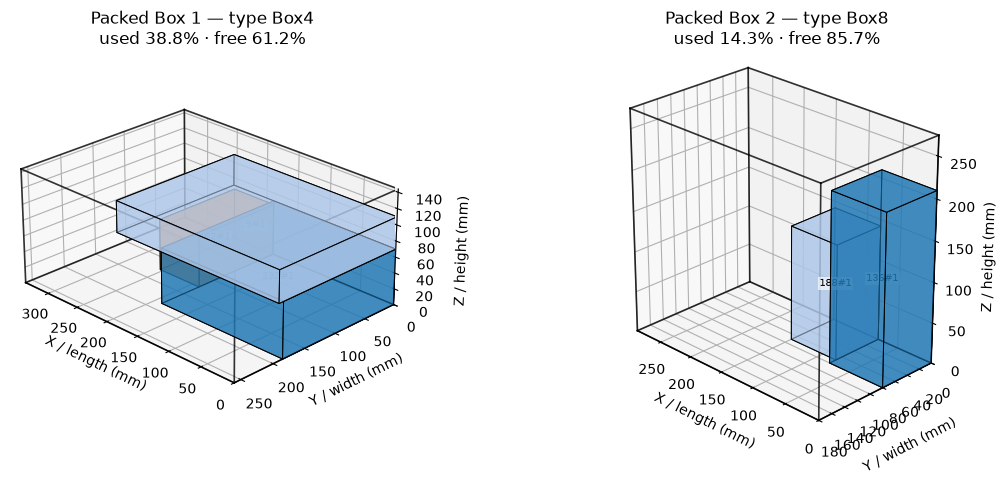

**Same order, deeper search:** Best starts from that validated Fast plan and searches for a better carton combination.

#### Best result — improved packing for the same order

Status,Strategy,Total cartons,Carton number,Carton,Box type,Item qty,Usable fill (%),Runtime (ms),Valid
success,best_fit,1,1,carton-1,Box8,5,48.76,22.756,True


Carton,Box type,Item,Packed L (mm),Packed W (mm),Packed H (mm),X (mm),Y (mm),Z (mm),Volume (mm^3)
carton-1,Box8,188#1,70.0,70.0,142.0,80.0,110.0,0.0,695800.0
carton-1,Box8,232#1,189.0,70.0,185.0,80.0,40.0,85.001,2447550.0
carton-1,Box8,9#1,255.0,40.0,192.0,0.0,0.0,19.001,1958400.0
carton-1,Box8,136#1,80.0,80.0,210.0,0.0,40.0,0.0,1344000.0
carton-1,Box8,62#1,125.0,65.0,65.0,150.0,110.0,149.001,528125.0


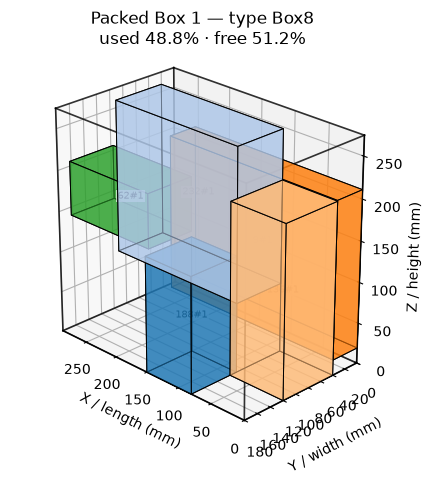

In [9]:
fast_better, fast_equal, fast_worse = comparison_counts(policy_pass_rows, 'fast')

display_table([
    {'Fast vs policy-compliant iHub': 'Better', 'Orders': fast_better},
    {'Fast vs policy-compliant iHub': 'Equal', 'Orders': fast_equal},
    {'Fast vs policy-compliant iHub': 'Worse', 'Orders': fast_worse},
])

fast_loss_rows = [
    row for row in policy_pass_rows
    if objective(row, 'fast') > ihub_objective(row)
]
fast_loss_example_id = 428 if any(row['order_id'] == 428 for row in fast_loss_rows) else fast_loss_rows[0]['order_id']

display(Markdown(f'### Concrete Fast loss — order {fast_loss_example_id}'))
compare_order(fast_loss_example_id)

display(Markdown(
    '**Functionality proof:** the Fast result below is not just a carton label. '
    'The decision log is available on demand, every XYZ placement is validated, '
    'and the 3D view renders every carton in the returned plan.'
))
fast_loss_proof = showcase_solver(
    fast_loss_example_id,
    'fast',
    'Fast result — multi-carton packing when the heuristic loses',
)

display(Markdown(
    '**Same order, deeper search:** Best starts from that validated Fast plan and '
    'searches for a better carton combination.'
))
fast_loss_best_proof = showcase_solver(
    fast_loss_example_id,
    'best',
    'Best result — improved packing for the same order',
)


## 6. What changes when we use Best?

Best starts from Fast's validated plan and searches for a better carton combination.

We compare Best against the same policy-compliant iHub population using exactly the same objective:

**fewest cartons → smallest largest carton → smallest total carton volume**.

In [10]:
best_better, best_equal, best_worse = comparison_counts(policy_pass_rows, 'best')

display_table([
    {'Best vs policy-compliant iHub': 'Better', 'Orders': best_better},
    {'Best vs policy-compliant iHub': 'Equal', 'Orders': best_equal},
    {'Best vs policy-compliant iHub': 'Worse', 'Orders': best_worse},
])

best_better_rows = [
    row for row in policy_pass_rows
    if objective(row, 'best') < ihub_objective(row)
]

fewer_carton_wins = [
    row for row in best_better_rows
    if row['best_cartons'] < row['ihub_cartons']
]
smaller_largest_wins = [
    row for row in best_better_rows
    if row['best_cartons'] == row['ihub_cartons']
    and row['best_largest_carton_volume_mm3'] < row['ihub_largest_carton_volume_mm3']
]
lower_total_volume_wins = [
    row for row in best_better_rows
    if row['best_cartons'] == row['ihub_cartons']
    and row['best_largest_carton_volume_mm3'] == row['ihub_largest_carton_volume_mm3']
    and row['best_external_volume_mm3'] < row['ihub_external_volume_mm3']
]

display_table([
    {'Why Best is better': 'Fewer cartons', 'Orders': len(fewer_carton_wins)},
    {'Why Best is better': 'Same carton count, smaller largest carton', 'Orders': len(smaller_largest_wins)},
    {'Why Best is better': 'Same carton count and largest carton, less total carton volume', 'Orders': len(lower_total_volume_wins)},
    {'Why Best is better': 'Total Best wins', 'Orders': len(best_better_rows)},
])

Best vs policy-compliant iHub,Orders
Better,67
Equal,1750
Worse,0


Why Best is better,Orders
Fewer cartons,2
"Same carton count, smaller largest carton",63
"Same carton count and largest carton, less total carton volume",2
Total Best wins,67


### 6.1 Best uses fewer cartons

This is the strongest optimization win. We first look for a representative order where Best also improves on Fast, so the example shows the value added by exact search rather than a case Fast had already solved equally well.

**Benchmark context:** 2 of the 1817 policy-compliant orders fall into this Best-win category.

**Representative order:** 1408

System,Policy,Cartons,Boxes,Largest carton volume (mm³),Total carton volume (mm³),Warm ms
Fast,PASS — validated,2,"Box5, Box6","24,752,000","45,526,000",30.068
Best,PASS — validated,1,Box9,"42,504,000","42,504,000",129.416
iHub,PASS — reported fill,2,"Box9, Box4","42,504,000","55,764,000",318.97


#### Validated Best packing — fewer cartons than iHub

Status,Strategy,Total cartons,Carton number,Carton,Box type,Item qty,Usable fill (%),Runtime (ms),Valid
success,best_fit,1,1,carton-1,Box9,10,63.09,108.754,True


Carton,Box type,Item,Packed L (mm),Packed W (mm),Packed H (mm),X (mm),Y (mm),Z (mm),Volume (mm^3)
carton-1,Box9,43#1,175.0,320.0,160.0,250.0,0.0,0.0,8960000.0
carton-1,Box9,268#1,190.0,110.0,40.0,250.0,192.0,229.001,836000.0
carton-1,Box9,136#1,80.0,80.0,210.0,170.0,80.0,0.0,1344000.0
carton-1,Box9,138#1,80.0,80.0,210.0,170.0,0.0,0.0,1344000.0
carton-1,Box9,9#1,255.0,192.0,40.0,170.0,0.0,229.001,1958400.0
carton-1,Box9,105#1,175.0,55.0,50.0,170.0,192.0,160.0,481250.0
carton-1,Box9,103#1,50.0,175.0,55.0,345.0,0.0,160.0,481250.0
carton-1,Box9,230#1,170.0,170.0,125.0,0.0,170.0,0.0,3612500.0
carton-1,Box9,230#2,170.0,170.0,125.0,0.0,0.0,104.001,3612500.0
carton-1,Box9,230#3,170.0,170.0,125.0,0.0,170.0,125.0,3612500.0


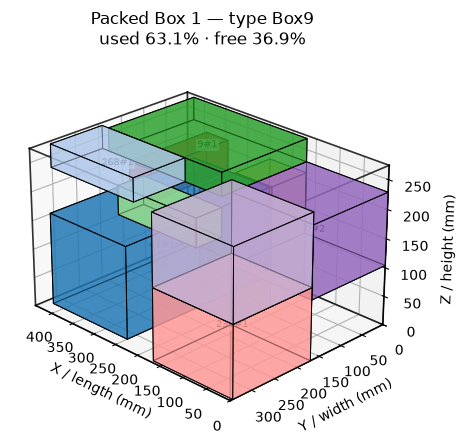

In [11]:
def preferred_example(rows):
    improved_over_fast = [
        row for row in rows
        if objective(row, 'best') < objective(row, 'fast')
    ]
    return (improved_over_fast or rows)[0]['order_id']

fewer_example_id = preferred_example(fewer_carton_wins)
display(Markdown(
    f'**Benchmark context:** {len(fewer_carton_wins)} of the '
    f'{len(policy_pass_rows)} policy-compliant orders fall into this Best-win category.'
))
display(Markdown(f'**Representative order:** {fewer_example_id}'))
compare_order(fewer_example_id)

fewer_example_proof = showcase_solver(
    fewer_example_id,
    'best',
    'Validated Best packing — fewer cartons than iHub',
)


### 6.2 Same number of cartons, but a smaller largest carton

When carton count is tied, the next objective is the size of the largest carton required.

This captures cases where both systems may use one carton, but Best proves that a smaller carton is sufficient.

**Benchmark context:** 63 of the 1817 policy-compliant orders fall into this Best-win category.

**Representative order:** 186

System,Policy,Cartons,Boxes,Largest carton volume (mm³),Total carton volume (mm³),Warm ms
Fast,PASS — validated,1,Box5,"20,774,000","20,774,000",4.738
Best,PASS — validated,1,Box8,"14,616,000","14,616,000",44.014
iHub,PASS — reported fill,1,Box5,"20,774,000","20,774,000",669.08


#### Validated Best packing — smaller largest carton

Status,Strategy,Total cartons,Carton number,Carton,Box type,Item qty,Usable fill (%),Runtime (ms),Valid
success,best_fit,1,1,carton-1,Box8,5,75.57,41.247,True


Carton,Box type,Item,Packed L (mm),Packed W (mm),Packed H (mm),X (mm),Y (mm),Z (mm),Volume (mm^3)
carton-1,Box8,304#1,155.0,170.0,145.0,90.0,0.0,125.0,3820750.0
carton-1,Box8,394#1,55.0,55.0,190.0,0.0,125.0,0.0,574750.0
carton-1,Box8,45#1,90.0,125.0,190.0,0.0,0.0,0.0,2137500.0
carton-1,Box8,45#2,190.0,90.0,125.0,90.0,90.0,0.0,2137500.0
carton-1,Box8,45#3,190.0,90.0,125.0,90.0,0.0,0.0,2137500.0


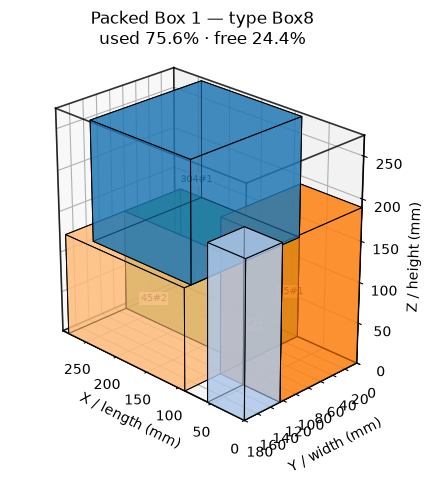

In [12]:
smaller_example_id = preferred_example(smaller_largest_wins)
display(Markdown(
    f'**Benchmark context:** {len(smaller_largest_wins)} of the '
    f'{len(policy_pass_rows)} policy-compliant orders fall into this Best-win category.'
))
display(Markdown(f'**Representative order:** {smaller_example_id}'))
compare_order(smaller_example_id)

smaller_example_proof = showcase_solver(
    smaller_example_id,
    'best',
    'Validated Best packing — smaller largest carton',
)


### 6.3 Same carton count and largest carton, but less total carton volume

If the first two objectives are tied, total external carton volume becomes the deciding factor.

This is especially relevant for multi-carton orders where the largest carton is the same but the remaining carton combination can still be improved.

**Benchmark context:** 2 of the 1817 policy-compliant orders fall into this Best-win category.

**Representative order:** 1532

System,Policy,Cartons,Boxes,Largest carton volume (mm³),Total carton volume (mm³),Warm ms
Fast,PASS — validated,2,"Box8, Box9","42,504,000","57,120,000",11.294
Best,PASS — validated,2,"Box4, Box9","42,504,000","55,764,000",238.428
iHub,PASS — reported fill,2,"Box9, Box8","42,504,000","57,120,000",234.5


#### Validated Best packing — lower total carton volume

Status,Strategy,Total cartons,Carton number,Carton,Box type,Item qty,Usable fill (%),Runtime (ms),Valid
success,best_fit,2,1,carton-1,Box4,1,19.25,233.657,True
success,best_fit,2,2,carton-2,Box9,7,69.0,233.657,True


Carton,Box type,Item,Packed L (mm),Packed W (mm),Packed H (mm),X (mm),Y (mm),Z (mm),Volume (mm^3)
carton-1,Box4,44#1,175.0,175.0,80.0,0.0,0.0,0.0,2450000.0
carton-2,Box9,140#1,70.0,70.0,200.0,350.0,0.0,0.0,980000.0
carton-2,Box9,44#2,80.0,175.0,175.0,350.0,160.0,0.0,2450000.0
carton-2,Box9,44#3,175.0,175.0,80.0,0.0,0.0,175.0,2450000.0
carton-2,Box9,44#4,175.0,175.0,80.0,175.0,0.0,175.0,2450000.0
carton-2,Box9,44#5,175.0,175.0,80.0,175.0,160.0,0.0,2450000.0
carton-2,Box9,43#1,320.0,160.0,175.0,0.0,0.0,0.0,8960000.0
carton-2,Box9,43#2,320.0,160.0,175.0,0.0,175.0,80.0,8960000.0


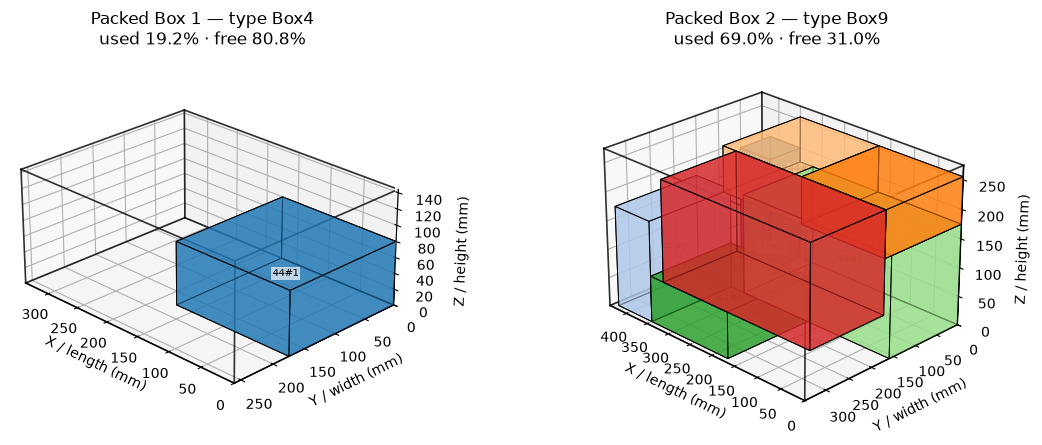

In [13]:
total_volume_example_id = preferred_example(lower_total_volume_wins)
display(Markdown(
    f'**Benchmark context:** {len(lower_total_volume_wins)} of the '
    f'{len(policy_pass_rows)} policy-compliant orders fall into this Best-win category.'
))
display(Markdown(f'**Representative order:** {total_volume_example_id}'))
compare_order(total_volume_example_id)

total_volume_example_proof = showcase_solver(
    total_volume_example_id,
    'best',
    'Validated Best packing — lower total carton volume',
)


## 7. What does the extra Best search cost when it actually creates value?

A generic latency average is less useful here.

We isolate the orders where **Best improves on Fast and is also better than iHub**. These are the cases where the additional exact search creates an incremental packing benefit over both alternatives.

For this subset we compare Fast, Best, and iHub latency together with the problem size.

In [14]:
dual_win_rows = [
    row for row in policy_pass_rows
    if objective(row, 'best') < objective(row, 'fast')
    and objective(row, 'best') < ihub_objective(row)
]

def runtime_summary(rows, key):
    values = [row[key] for row in rows]
    return {
        'Median (ms)': round(statistics.median(values), 3),
        'P95 (ms)': round(percentile_95(values), 3),
        'Min (ms)': round(min(values), 3),
        'Max (ms)': round(max(values), 3),
    }

display(Markdown(
    f'**Value-creating Best subset:** {len(dual_win_rows)} orders where Best is better than both Fast and iHub.'
))

display_table([
    {'System': 'Fast', **runtime_summary(dual_win_rows, 'fast_runtime_ms')},
    {'System': 'Best', **runtime_summary(dual_win_rows, 'best_runtime_ms')},
    {'System': 'iHub', **runtime_summary(dual_win_rows, 'ihub_latency_ms')},
])

item_counts = [row['physical_items'] for row in dual_win_rows]
candidate_counts = [
    row.get('candidate_boxes', len(ihub_records[row['order_id']]['input']['Bins']['BinsList']))
    for row in dual_win_rows
]
display_table([
    {
        'Problem-size measure': 'Physical items per order',
        'Min': min(item_counts),
        'Median': statistics.median(item_counts),
        'Max': max(item_counts),
    },
    {
        'Problem-size measure': 'Candidate carton types',
        'Min': min(candidate_counts),
        'Median': statistics.median(candidate_counts),
        'Max': max(candidate_counts),
    },
])

**Value-creating Best subset:** 50 orders where Best is better than both Fast and iHub.

System,Median (ms),P95 (ms),Min (ms),Max (ms)
Fast,3.929,16.627,1.398,18.489
Best,55.526,294.139,18.695,332.671
iHub,194.06,460.55,155.25,718.39


Problem-size measure,Min,Median,Max
Physical items per order,4,6.0,13
Candidate carton types,6,6.0,6


### Latency by order size

To make the scaling behavior visible, the same value-creating subset is grouped by physical item count.

This is descriptive evidence for the current development scale, not a claim that exact-search latency will remain flat as orders become larger.

In [15]:
def item_bucket(count):
    if count <= 6:
        return '1–6 items'
    if count <= 10:
        return '7–10 items'
    if count <= 15:
        return '11–15 items'
    return '16+ items'

bucket_order = ['1–6 items', '7–10 items', '11–15 items', '16+ items']
scale_rows = []
for bucket in bucket_order:
    rows = [row for row in dual_win_rows if item_bucket(row['physical_items']) == bucket]
    if not rows:
        continue
    scale_rows.append({
        'Physical items': bucket,
        'Orders': len(rows),
        'Candidate cartons (median)': statistics.median(row['candidate_boxes'] for row in rows),
        'Fast median (ms)': round(statistics.median(row['fast_runtime_ms'] for row in rows), 3),
        'Best median (ms)': round(statistics.median(row['best_runtime_ms'] for row in rows), 3),
        'Best P95 (ms)': round(percentile_95([row['best_runtime_ms'] for row in rows]), 3),
        'iHub median (ms)': round(statistics.median(row['ihub_latency_ms'] for row in rows), 3),
    })

display_table(scale_rows)

Physical items,Orders,Candidate cartons (median),Fast median (ms),Best median (ms),Best P95 (ms),iHub median (ms)
1–6 items,28,6.0,3.022,43.83,106.281,296.73
7–10 items,19,6,5.464,71.671,332.671,183.39
11–15 items,3,6,9.264,294.139,299.698,195.75


## 8. Conclusion: bring the 2,000 orders back together

The conclusion returns to the same benchmark funnel used throughout the demo. No new comparison rule is introduced at the end.

In [16]:
best_improves_fast = sum(
    objective(row, 'best') < objective(row, 'fast')
    for row in benchmark_rows
)
best_ties_fast = sum(
    objective(row, 'best') == objective(row, 'fast')
    for row in benchmark_rows
)

display_table([
    {'Step': 'Development orders', 'Orders': order_count, 'Meaning': 'Full benchmark population'},
    {'Step': 'iHub Box9 policy failures', 'Orders': len(policy_fail_rows), 'Meaning': 'Separated before optimization comparison'},
    {'Step': 'Fair policy-compliant comparisons', 'Orders': len(policy_pass_rows), 'Meaning': 'Used for Fast/Best vs iHub'},
    {'Step': 'Fast better / equal / worse vs iHub', 'Orders': f'{fast_better} / {fast_equal} / {fast_worse}', 'Meaning': 'Heuristic baseline'},
    {'Step': 'Best better / equal / worse vs iHub', 'Orders': f'{best_better} / {best_equal} / {best_worse}', 'Meaning': 'Exact-assisted result'},
    {'Step': 'Best improves / ties Fast', 'Orders': f'{best_improves_fast} / {best_ties_fast}', 'Meaning': 'Incremental value of Best'},
])

display(Markdown(
    f"""
**What the benchmark says**

- Start with **{order_count:,} orders**.
- **{len(policy_fail_rows):,}** iHub references exceed the observable Box9 fill policy and are separated before optimization scoring.
- On the remaining **{len(policy_pass_rows):,}** fair comparisons, Best is **{best_better} better, {best_equal} equal, and {best_worse} worse** than iHub.
- Those Best wins break down into **{len(fewer_carton_wins)} fewer-carton wins**, **{len(smaller_largest_wins)} smaller-largest-carton wins**, and **{len(lower_total_volume_wins)} lower-total-volume wins**.
- Best improves Fast on **{best_improves_fast}** orders while retaining Fast as the validated fallback.
- The latency section isolates the **{len(dual_win_rows)}** orders where Best is better than both Fast and iHub, so the extra search cost is interpreted together with the problem size where it created value.
"""
))

Step,Orders,Meaning
Development orders,2000,Full benchmark population
iHub Box9 policy failures,183,Separated before optimization comparison
Fair policy-compliant comparisons,1817,Used for Fast/Best vs iHub
Fast better / equal / worse vs iHub,18 / 1514 / 285,Heuristic baseline
Best better / equal / worse vs iHub,67 / 1750 / 0,Exact-assisted result
Best improves / ties Fast,402 / 1598,Incremental value of Best



**What the benchmark says**

- Start with **2,000 orders**.
- **183** iHub references exceed the observable Box9 fill policy and are separated before optimization scoring.
- On the remaining **1,817** fair comparisons, Best is **67 better, 1750 equal, and 0 worse** than iHub.
- Those Best wins break down into **2 fewer-carton wins**, **63 smaller-largest-carton wins**, and **2 lower-total-volume wins**.
- Best improves Fast on **402** orders while retaining Fast as the validated fallback.
- The latency section isolates the **50** orders where Best is better than both Fast and iHub, so the extra search cost is interpreted together with the problem size where it created value.


## 9. Appendix: check that iHub's stored answer does not influence our solver

The benchmark uses iHub only after solving for comparison. This falsification check deliberately changes a stored iHub answer and verifies that Fast and Best recommendations remain unchanged.

In [17]:
audit_order_id = fast_loss_example_id
audit_original = copy.deepcopy(ihub_records[audit_order_id])
audit_changed = copy.deepcopy(audit_original)
audit_changed['output']['Data']['BinsPacked'] = [{'Code': 'Box9', 'UsedSpace': 1.0}]
audit_changed['latency_ms'] = 999_999

audit_before = benchmark([audit_original])[0]
audit_after = benchmark([audit_changed])[0]
solver_fields = (
    'fast_boxes', 'fast_cartons', 'fast_external_volume_mm3',
    'best_boxes', 'best_cartons', 'best_external_volume_mm3',
)
assert {field: audit_before[field] for field in solver_fields} == {
    field: audit_after[field] for field in solver_fields
}
assert audit_before['ihub_boxes'] != audit_after['ihub_boxes']

display_table([
    {
        'Reference record': 'Original',
        'Stored iHub answer': audit_before['ihub_boxes'],
        'Fast recommendation': audit_before['fast_boxes'],
        'Best recommendation': audit_before['best_boxes'],
    },
    {
        'Reference record': 'iHub answer deliberately changed',
        'Stored iHub answer': audit_after['ihub_boxes'],
        'Fast recommendation': audit_after['fast_boxes'],
        'Best recommendation': audit_after['best_boxes'],
    },
])
display(Markdown('**PASS:** changing the stored iHub answer changes the comparison label, but not either solver recommendation.'))

Reference record,Stored iHub answer,Fast recommendation,Best recommendation
Original,Box8,"Box4,Box8",Box8
iHub answer deliberately changed,Box9,"Box4,Box8",Box8


**PASS:** changing the stored iHub answer changes the comparison label, but not either solver recommendation.